# GPT Cross-Eval Ratings Analysis

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
import scipy.stats as stats
from scipy.stats import spearmanr, pearsonr, binomtest
from scipy.stats import kendalltau


In [20]:
repo_root = Path('/playpen-ssd/wokwen/projects/autoeval_chatbot')

cross_eval_paths = {
    "GPT": repo_root / "ratings" / "gpt" / "cross_eval_ratings.csv",
    "LLaMA": repo_root / "ratings" / "llama" / "cross_eval_ratings.csv",
    "Qwen": repo_root / "ratings" / "qwen" / "cross_eval_ratings.csv",
}

def load_cross_eval(path, evaluator_name):
    df = pd.read_csv(path, on_bad_lines="skip")
    df["evaluator"] = evaluator_name
    return df

dfs = []
for evaluator, path in cross_eval_paths.items():
    df_tmp = load_cross_eval(path, evaluator)
    dfs.append(df_tmp)
    print(f"{evaluator}: {df_tmp.shape}")

df_cross_all = pd.concat(dfs, ignore_index=True)

print("\nCombined shape:", df_cross_all.shape)
df_cross_all.head()

GPT: (500, 11)
LLaMA: (400, 11)
Qwen: (380, 11)

Combined shape: (1280, 11)


,Conversation_Id,Actual_ConvA,Actual_ConvB,Actual_ConvC,ConvA_Rating,ConvA_Reason,ConvB_Rating,ConvB_Reason,ConvC_Rating,ConvC_Reason,evaluator
0,0,prompt_no_data,data_no_prompt,chatbot,6,The chatbot provided supportive responses but ...,5,The chatbot offered some empathetic responses ...,9,"The chatbot delivered accurate, evidence-based...",GPT
1,1,data_no_prompt,prompt_no_data,chatbot,4,The chatbot repeatedly redirected the user to ...,9,The chatbot provided empathetic and relevant r...,8,The chatbot offered accurate information and s...,GPT
2,2,chatbot,prompt_no_data,data_no_prompt,9,"The chatbot provided accurate information, add...",7,While the chatbot offered relevant questions a...,6,The chatbot primarily redirected the user to p...,GPT
3,3,data_no_prompt,prompt_no_data,chatbot,3,The chatbot repeatedly redirected the user to ...,9,The chatbot provided empathetic and relevant r...,8,The chatbot offered accurate information and s...,GPT
4,4,chatbot,prompt_no_data,data_no_prompt,9,"The chatbot provided comprehensive, empathetic...",8,The chatbot demonstrated good understanding an...,5,The chatbot frequently repeated questions and ...,GPT


## Unblind Evaluators

In [21]:
def unblind_cross_eval(df):
    rows = []

    for _, r in df.iterrows():
        conv_id = r["Conversation_Id"]
        evaluator = r["evaluator"]

        slot_to_system = {
            "A": r["Actual_ConvA"],
            "B": r["Actual_ConvB"],
            "C": r["Actual_ConvC"],
        }

        slot_to_rating = {
            "A": r["ConvA_Rating"],
            "B": r["ConvB_Rating"],
            "C": r["ConvC_Rating"],
        }

        slot_to_reason = {
            "A": r.get("ConvA_Reason", None),
            "B": r.get("ConvB_Reason", None),
            "C": r.get("ConvC_Reason", None),
        }

        for slot in ["A", "B", "C"]:
            rows.append({
                "conversation_id": conv_id,
                "evaluator": evaluator,
                "system": slot_to_system[slot],
                "rating": pd.to_numeric(slot_to_rating[slot], errors="coerce"),
                "reason": slot_to_reason[slot],
            })

    out = pd.DataFrame(rows)

    # Standardize system names
    out["system"] = out["system"].replace({
        "chatbot": "full"
    })

    return out

df_cross_long = unblind_cross_eval(df_cross_all)

print("Long shape:", df_cross_long.shape)
print("\nSystems:")
print(df_cross_long["system"].value_counts())

print("\nEvaluators:")
print(df_cross_long["evaluator"].value_counts())

df_cross_long.head()

Long shape: (3840, 5)

Systems:
system
prompt_no_data    1280
data_no_prompt    1280
full              1280
Name: count, dtype: int64

Evaluators:
evaluator
GPT      1500
LLaMA    1200
Qwen     1140
Name: count, dtype: int64


,conversation_id,evaluator,system,rating,reason
0,0,GPT,prompt_no_data,6,The chatbot provided supportive responses but ...
1,0,GPT,data_no_prompt,5,The chatbot offered some empathetic responses ...
2,0,GPT,full,9,"The chatbot delivered accurate, evidence-based..."
3,1,GPT,data_no_prompt,4,The chatbot repeatedly redirected the user to ...
4,1,GPT,prompt_no_data,9,The chatbot provided empathetic and relevant r...


In [22]:
import re

def remap_chatbots(df, conv_prefixes=None):
    if conv_prefixes is None:
        conv_prefixes = ['conva', 'convb', 'convc']

    rating_cols = {}
    for p in conv_prefixes:
        cand = next(
            (c for c in df.columns
             if re.fullmatch(p + r'(_|-)?rating', c, flags=re.IGNORECASE)
             or c.lower().startswith(p + '_rating')),
            None
        )
        if cand is None:
            cand = next((c for c in df.columns if c.lower().startswith(p) and 'rating' in c.lower()), None)
        rating_cols[p] = cand

    actual_cols = {
        p: next((c for c in df.columns if c.lower() == f'actual_{p}'), None)
        for p in conv_prefixes
    }

    rows = []
    for _, row in df.iterrows():
        conv_row = {
            'conversation_id': row['Conversation_Id'],
            'evaluator': row['evaluator']
        }

        for p in conv_prefixes:
            if actual_cols.get(p) and pd.notna(row.get(actual_cols[p])):
                bot_type = str(row.get(actual_cols[p])).strip().lower()
            else:
                bot_type = p

            if bot_type == "chatbot":
                bot_type = "full"

            rc = rating_cols.get(p)
            rating = row.get(rc) if rc in df.columns else np.nan
            conv_row[f'{bot_type}_rating'] = pd.to_numeric(rating, errors='coerce')

        rows.append(conv_row)

    return pd.DataFrame(rows)

ratings_wide_all = remap_chatbots(df_cross_all)

print("Wide shape:", ratings_wide_all.shape)
print("\nColumns:", ratings_wide_all.columns.tolist())

print("\nRows per evaluator:")
print(ratings_wide_all["evaluator"].value_counts())

print("\nMissing values per rating column:")
print(ratings_wide_all[[c for c in ratings_wide_all.columns if c.endswith("_rating")]].isna().sum())

ratings_wide_all.head()

Wide shape: (1280, 5)

Columns: ['conversation_id', 'evaluator', 'prompt_no_data_rating', 'data_no_prompt_rating', 'full_rating']

Rows per evaluator:
evaluator
GPT      500
LLaMA    400
Qwen     380
Name: count, dtype: int64

Missing values per rating column:
prompt_no_data_rating    0
data_no_prompt_rating    0
full_rating              0
dtype: int64


,conversation_id,evaluator,prompt_no_data_rating,data_no_prompt_rating,full_rating
0,0,GPT,6,5,9
1,1,GPT,9,4,8
2,2,GPT,7,6,9
3,3,GPT,9,3,8
4,4,GPT,8,5,9


### Box Plots

/tmp/ipykernel_1227203/894705834.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["full", "prompt_no_data", "data_no_prompt"], rotation=30)
/tmp/ipykernel_1227203/894705834.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["full", "prompt_no_data", "data_no_prompt"], rotation=30)
/tmp/ipykernel_1227203/894705834.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["full", "prompt_no_data", "data_no_prompt"], rotation=30)


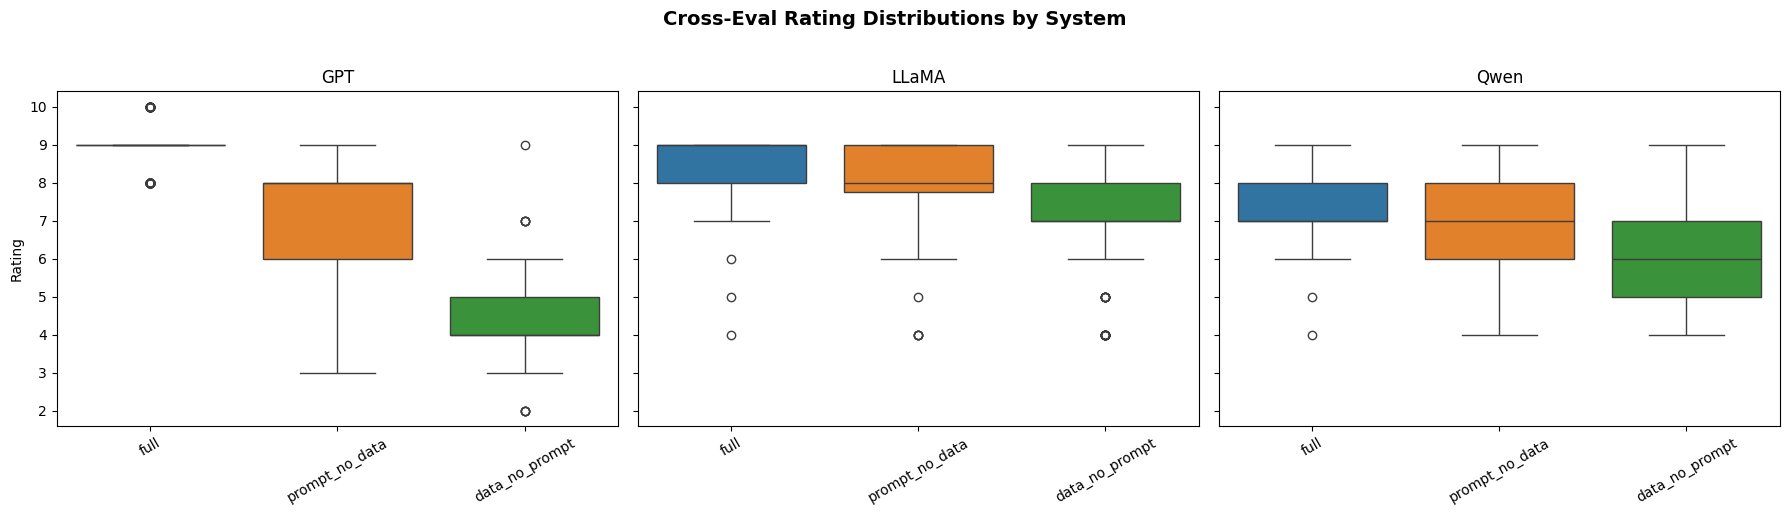

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

evaluators = ["GPT", "LLaMA", "Qwen"]
systems = ["full_rating", "prompt_no_data_rating", "data_no_prompt_rating"]

for ax, evaluator in zip(axes, evaluators):
    sub = ratings_wide_all[ratings_wide_all["evaluator"] == evaluator]
    
    plot_data = [sub[sys].values for sys in systems]
    
    sns.boxplot(data=plot_data, ax=ax)
    
    ax.set_xticklabels(["full", "prompt_no_data", "data_no_prompt"], rotation=30)
    ax.set_title(evaluator)
    ax.set_xlabel("")
    ax.set_ylabel("Rating" if evaluator == "GPT" else "")

fig.suptitle("Cross-Eval Rating Distributions by System", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("cross_eval_boxplots.png", dpi=300)
plt.show()

### Win Rates

In [24]:
def win_rate(df, a, b):
    return (df[a] > df[b]).mean()

evaluators = ["GPT", "LLaMA", "Qwen"]

for evaluator in evaluators:
    sub = ratings_wide_all[ratings_wide_all["evaluator"] == evaluator]
    
    print(f"\n{evaluator} cross-eval win rates:")
    print("Full > Prompt_no_data:", win_rate(sub, "full_rating", "prompt_no_data_rating"))
    print("Full > Data_no_prompt:", win_rate(sub, "full_rating", "data_no_prompt_rating"))
    print("Prompt_no_data > Data_no_prompt:", win_rate(sub, "prompt_no_data_rating", "data_no_prompt_rating"))


GPT cross-eval win rates:
Full > Prompt_no_data: 0.926
Full > Data_no_prompt: 1.0
Prompt_no_data > Data_no_prompt: 0.99

LLaMA cross-eval win rates:
Full > Prompt_no_data: 0.625
Full > Data_no_prompt: 0.8525
Prompt_no_data > Data_no_prompt: 0.78

Qwen cross-eval win rates:
Full > Prompt_no_data: 0.46578947368421053
Full > Data_no_prompt: 0.7342105263157894
Prompt_no_data > Data_no_prompt: 0.6789473684210526


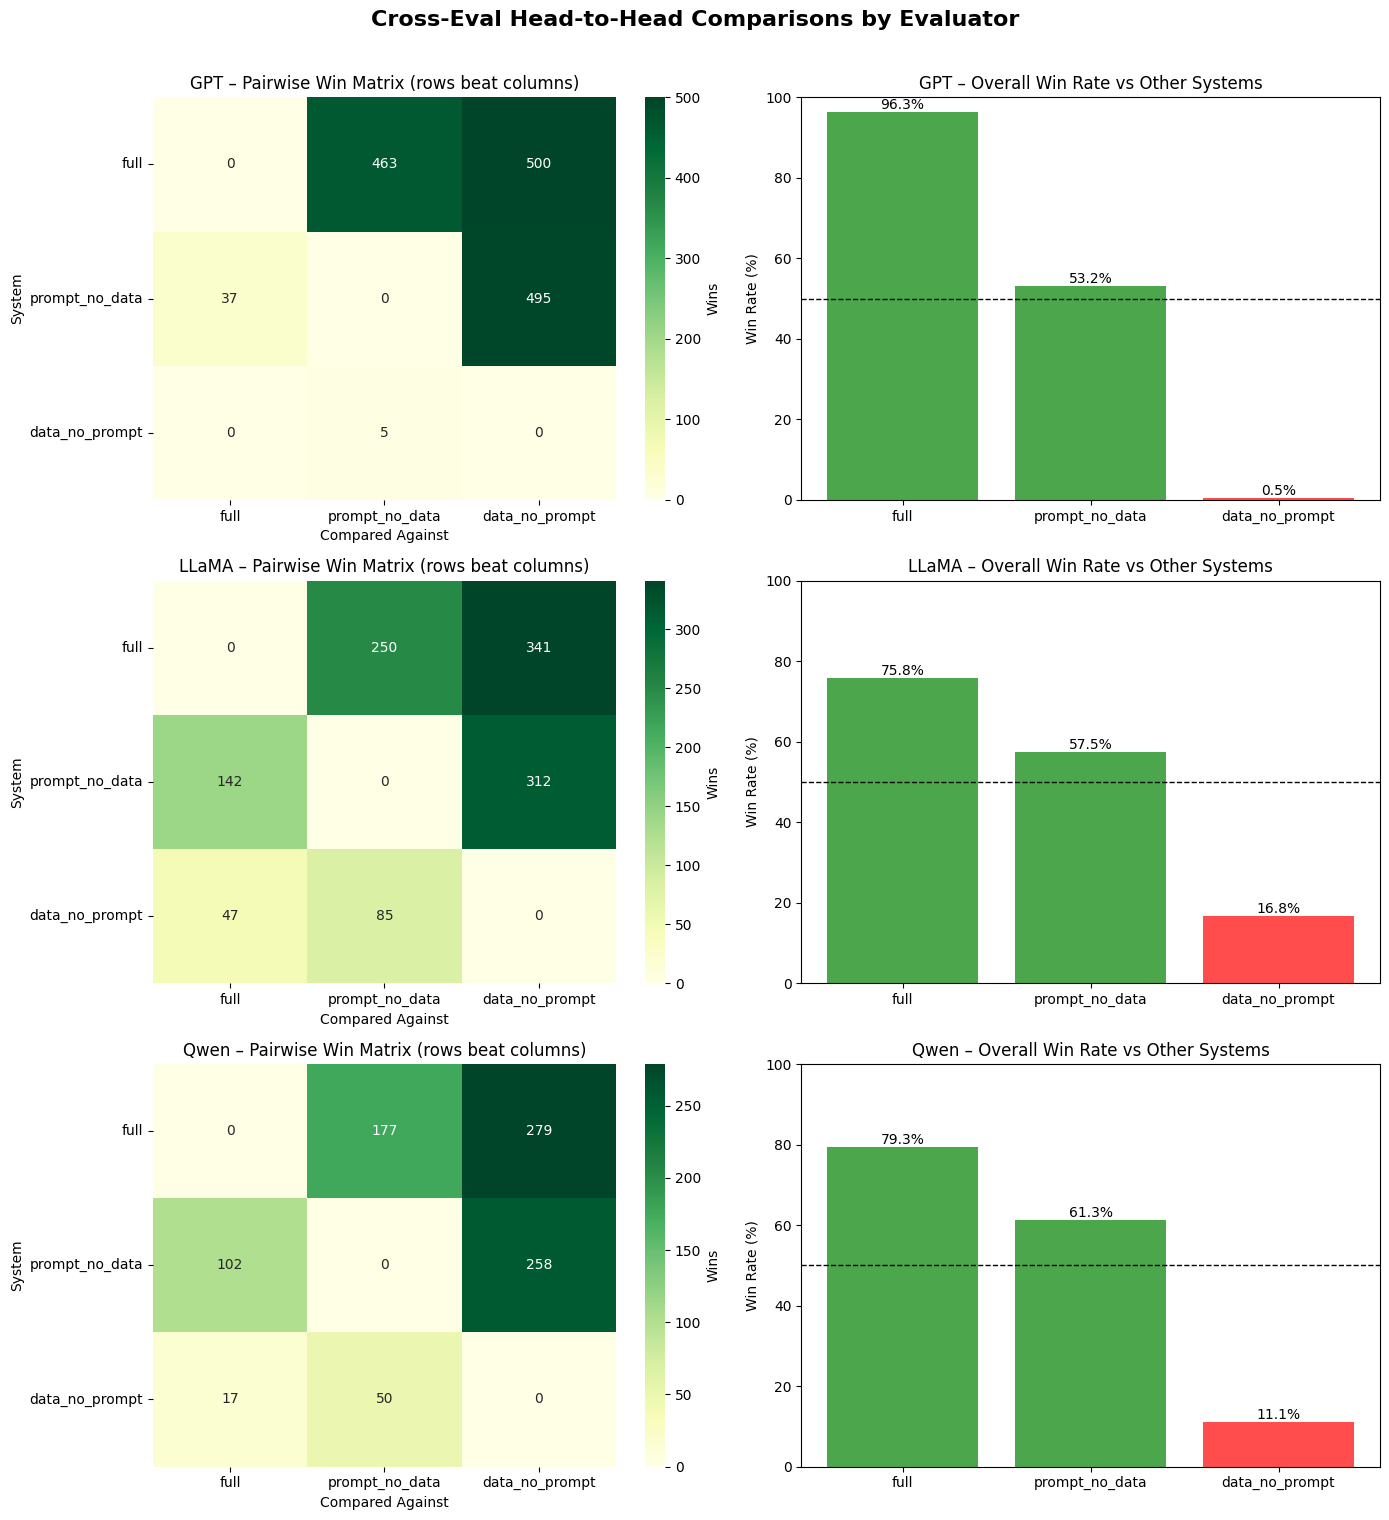

In [29]:
systems = ["full", "prompt_no_data", "data_no_prompt"]
evaluators = ["GPT", "LLaMA", "Qwen"]

def build_win_matrix(sub_df, systems):
    win_matrix = pd.DataFrame(0, index=systems, columns=systems)

    for a in systems:
        for b in systems:
            if a == b:
                continue
            win_matrix.loc[a, b] = (sub_df[f"{a}_rating"] > sub_df[f"{b}_rating"]).sum()
    return win_matrix

# Create a single figure with 3 rows (one per evaluator) and 2 columns
fig, axes = plt.subplots(3, 2, figsize=(14, 15))

for row, evaluator in enumerate(evaluators):
    sub = ratings_wide_all[ratings_wide_all["evaluator"] == evaluator]
    win_matrix = build_win_matrix(sub, systems)

    # Heatmap (left column)
    ax = axes[row, 0]
    sns.heatmap(
        win_matrix,
        annot=True,
        fmt='d',
        cmap='YlGn',
        ax=ax,
        cbar_kws={'label': 'Wins'}
    )
    ax.set_title(f'{evaluator} – Pairwise Win Matrix (rows beat columns)')
    ax.set_xlabel('Compared Against')
    ax.set_ylabel('System')

    # Win-rate bar chart (right column)
    win_rates = {}
    for system in systems:
        total_wins = win_matrix.loc[system].sum()
        total_losses = win_matrix[system].sum()
        total_competitions = total_wins + total_losses
        if total_competitions > 0:
            win_rates[system] = 100 * total_wins / total_competitions

    ax = axes[row, 1]
    systems_sorted = sorted(systems, key=lambda x: win_rates.get(x, 0), reverse=True)
    rates_sorted = [win_rates[s] for s in systems_sorted]
    colors = ['green' if r > 50 else 'red' for r in rates_sorted]

    bars = ax.bar(systems_sorted, rates_sorted, color=colors, alpha=0.7)
    ax.axhline(y=50, color='black', linestyle='--', linewidth=1)
    ax.set_ylabel('Win Rate (%)')
    ax.set_title(f'{evaluator} – Overall Win Rate vs Other Systems')
    ax.set_ylim([0, 100])

    for bar, rate in zip(bars, rates_sorted):
        ax.text(
            bar.get_x() + bar.get_width()/2.,
            rate,
            f'{rate:.1f}%',
            ha='center',
            va='bottom'
        )

fig.suptitle("Cross-Eval Head-to-Head Comparisons by Evaluator", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("cross_eval_wins_combined.png", dpi=300, bbox_inches='tight')
plt.show()

## Correlation & Agreement Analysis

Analyze how consistently the three bot types are rated across conversations.

In [26]:
# Prepare ratings for correlation analysis
ratings_for_corr = ratings_wide_all[[c for c in ratings_wide_all.columns if c.endswith('_rating')]].copy()
ratings_for_corr.columns = [c.replace('_rating', '') for c in ratings_for_corr.columns]

print("Pairwise Pearson Correlations:")
pearson_corr = ratings_for_corr.corr(method='pearson')
display(pearson_corr)

print("\nPairwise Spearman Rank Correlations:")
spearman_corr = ratings_for_corr.corr(method='spearman')
display(spearman_corr)

Pairwise Pearson Correlations:


,prompt_no_data,data_no_prompt,full
prompt_no_data,1.000000,0.388914,0.092219
data_no_prompt,0.388914,1.000000,-0.169326
full,0.092219,-0.169326,1.000000



Pairwise Spearman Rank Correlations:


,prompt_no_data,data_no_prompt,full
prompt_no_data,1.000000,0.356818,0.066874
data_no_prompt,0.356818,1.000000,-0.215326
full,0.066874,-0.215326,1.000000


## Pairwise Win Analysis

Head-to-head comparison: which bot type gets the highest rating in each conversation?


## Kendall Tau Analysis

In [27]:
ratings_wide_all.columns

Index(['conversation_id', 'evaluator', 'prompt_no_data_rating',
       'data_no_prompt_rating', 'full_rating'],
      dtype='object')

In [28]:

def compute_rank(df):
    return df[["full_rating", "prompt_no_data_rating", "data_no_prompt_rating"]]\
        .rank(axis=1, ascending=False)

evaluators = ["GPT", "LLaMA", "Qwen"]

for evaluator in evaluators:
    sub = ratings_wide_all[ratings_wide_all["evaluator"] == evaluator]
    ranks = compute_rank(sub)

    tau_fp, p_fp = kendalltau(ranks["full_rating"], ranks["prompt_no_data_rating"])
    tau_fd, p_fd = kendalltau(ranks["full_rating"], ranks["data_no_prompt_rating"])
    tau_pd, p_pd = kendalltau(ranks["prompt_no_data_rating"], ranks["data_no_prompt_rating"])

    print(f"\n{evaluator} Kendall Tau:")
    print(f"  Full vs Prompt: tau={tau_fp:.4f}, p={p_fp:.4e}")
    print(f"  Full vs Data:   tau={tau_fd:.4f}, p={p_fd:.4e}")
    print(f"  Prompt vs Data: tau={tau_pd:.4f}, p={p_pd:.4e}")


GPT Kendall Tau:
  Full vs Prompt: tau=-0.9392, p=1.4327e-98
  Full vs Data:   tau=0.0284, p=5.2565e-01
  Prompt vs Data: tau=-0.3570, p=1.1518e-15

LLaMA Kendall Tau:
  Full vs Prompt: tau=-0.6551, p=6.8471e-48
  Full vs Data:   tau=-0.2070, p=7.6538e-06
  Prompt vs Data: tau=-0.4015, p=1.5048e-18

Qwen Kendall Tau:
  Full vs Prompt: tau=-0.6432, p=1.4918e-50
  Full vs Data:   tau=-0.2272, p=3.5276e-07
  Prompt vs Data: tau=-0.3516, p=1.5266e-15
